# 3H — Gênese: que estado físico precede o nascimento de El Niño e Super El Niño?

**Pergunta específica que este notebook responde:** *que valores as variáveis físicas assumem ANTES do onset de cada evento, e o estado precursor separa, já na gênese, os eventos que virarão super/strong dos moderate/weak? Como cada variável evolui pela sequência gênese → crescimento → pico → decaimento?*

**Objetivo:** transformar os leads estatísticos do 3C–3E em leitura *event-centered*: compostos alinhados ao **onset** (não ao pico), estado precursor médio por classe, e a evolução completa do ciclo de vida variável a variável.

**Justificativa:** o 3C–3E respondeu "o que correlaciona com a SSTA semanal, com que lag" — associação contínua. Mas a pergunta operacional do parecer é outra: *dado um estado do Pacífico hoje, ele se parece com o que precedeu eventos passados, e de que classe?* Isso exige alinhar os precursores ao nascimento de cada evento e comparar classes. Com 12 eventos, a leitura é **descritiva e de separação** (não teste de hipótese — n pequeno demais; usar Spearman e ranges, nunca p-valores agressivos). Este notebook também consolida a narrativa física do ciclo de vida exigida pela pergunta-título da Fase 3.

**Metodologia.**
1. **Compostos onset-alinhados**: para cada evento, extraem-se as 14 variáveis semanais de −52 semanas antes do onset até +78 depois; compostos por classe agrupada (super+strong = "fortes"; moderate+weak = "fracos") para reduzir ruído com n=12.
2. **Tabela de estado precursor**: valor médio de cada variável em −26, −13 e 0 semanas do onset, por classe agrupada, com range (min–max) — o "retrato da gênese".
3. **Separação na gênese**: Spearman entre o estado precursor (média −26..0) e a intensidade final do evento (SSTA de pico), por variável — quais variáveis "sabiam" cedo o tamanho do evento.
4. **Ciclo de vida completo**: evolução composta de recarga (D20/WWV), resposta dinâmica (SSH/tilt), acoplamento (τx) e severidade (DHW) pelas quatro fases, para eventos fortes.

**Saídas:** `phase3H_estado_precursor_por_classe.csv`, `phase3H_separacao_genese.csv`, `phase3H_compostos_onset.csv` + composto multipainel e retrato da gênese (figuras).

**Limites:** n=12 eventos (3 super, 3 strong, 2 moderate, 4 weak); nada aqui é skill preditivo — é caracterização de estados precursores. A promoção a previsão é papel da Fase 5 (walk-forward vs persistência/climatologia).

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import fase3_utils as u

weekly = pd.read_csv(u.FEAT / 'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev = u.load_events()
ev['grupo'] = np.where(ev['peak_class'].isin(['super_el_nino','strong_el_nino']), 'forte', 'fraco')
VARS = ['nino34_ssta','d20_m','wwv','tilt_m','ssh_m','ohc_0_300','dhw_12w','tau_x_proxy_nino34_pa','atl4_ssta']
LAGS = list(range(-52, 79))

def onset_aligned(series, onset):
    idx = series.index.get_indexer([onset], method='nearest')[0]
    seg = series.iloc[max(0, idx-52): idx+79]
    rel = ((seg.index - series.index[idx]).days / 7).round().astype(int)
    return pd.Series(seg.values, index=rel).reindex(LAGS)

# compostos onset-alinhados por grupo
comps = {}
for grupo, g in ev.groupby('grupo'):
    mats = {v: [] for v in VARS}
    for _, e in g.iterrows():
        for v in VARS:
            mats[v].append(onset_aligned(weekly[v], e.event_start))
    comps[grupo] = pd.DataFrame({v: pd.DataFrame(m).mean() for v, m in mats.items()})
out = pd.concat(comps, names=['grupo','semana_rel_onset'])
out.to_csv(u.STATS / 'phase3H_compostos_onset.csv')
print('[tabela] phase3H_compostos_onset.csv | grupos:', {k: len(g) for k, g in ev.groupby('grupo')})

[tabela] phase3H_compostos_onset.csv | grupos: {'forte': 6, 'fraco': 6}


## Proveniência e composição dos compostos (rastreabilidade)

**Eventos que compõem cada grupo** (definidos em `nino34_oisst_event_reference.csv`, derivados da própria SSTA OISST — critério: média 3 meses ≥ 0,5 °C por 5+ meses):

- **forte (n=6)** = 3 super (1982/83, 1997/98, 2014/16) + 3 strong (1991/92, 2009/10, 2023/24)
- **fraco (n=6)** = 2 moderate (1986/88, 2002/03) + 4 weak (1994/95, 2004, 2006/07, 2018/19)

**Alinhamento:** cada série semanal é recortada de −52 a +78 semanas em torno do **onset** (`event_start` = primeiro mês do critério, mapeado para a semana `W-SUN` mais próxima). **Composto = média simples entre os eventos do grupo**, semana a semana (sem ponderação por intensidade). O evento 2025/26 em curso **não** entra (sem fim registrado).

**Fontes por variável (janelas reais):**

| Variável | Fonte primária | Janela | Observação |
|---|---|---|---|
| SSTA Niño 3.4 | NOAA OISST v2.1 local | 1981-09+ | clim. dia-do-ano 1991–2020, janela 15d |
| D20, WWV, tilt, SSH, OHC 0-300 | UFS (1981–92, ponte) → GLORYS12 (1993+) → GLO12 (cauda) | sensibilidade 1993+ | eventos 1982/83, 1986/88 e 1991/92 usam trecho UFS na gênese — citar ao interpretar |
| DHW 12 sem | derivado da SSTA OISST | válido 1981-11-23+ | limiar 1 °C, acumulação diária |
| τx proxy | ERA5 u10, caixa Niño 3.4 | 1981+ | proxy (protocolo pede Niño 4); só fase temporal |
| ATL4 SSTA | OISST global local | 1981-09+ | controle |

**Tratamentos por figura:** 3H-1 (multipainel) e tabelas usam os compostos **sem suavização**, em unidades físicas. A 3H-3 (síntese) usa **só o grupo forte (n=6)**, z-score calculado sobre a própria janela −52..+78 do composto, e **suavização por média móvel centrada de 5 semanas** (apenas visual — as tabelas de decisão não são suavizadas). Tabela 3H-1: médias em janelas de ±2 semanas em torno dos marcos −26/−13/0. Tabela 3H-2: Spearman sobre a média −26..0 por evento (n=12).

In [2]:
# Tabela de proveniencia: exatamente quais onsets entram em cada composto
prov = ev[['event_id','peak_class','grupo','event_start','peak_time','event_end','duration_months','peak_monthly_ssta_c']].copy()
prov.columns = ['evento','classe','grupo_composto','onset(event_start)','pico_ssta','fim','duracao_meses','ssta_pico_c']
u.save_table(prov, 'phase3H_proveniencia_eventos.csv', index=False)
print(f"forte n={len(prov[prov.grupo_composto=='forte'])} | fraco n={len(prov[prov.grupo_composto=='fraco'])} | alinhamento: onset -> semana W-SUN mais proxima; composto = media simples")
prov

[tabela] data/processed/parquet/statistics/phase3H_proveniencia_eventos.csv
forte n=6 | fraco n=6 | alinhamento: onset -> semana W-SUN mais proxima; composto = media simples


,evento,classe,grupo_composto,onset(event_start),pico_ssta,fim,duracao_meses,ssta_pico_c
0,el_nino_oisst_1982_1983,super_el_nino,forte,1982-07-01,1983-01-01,1983-05-01,11,2.212520
1,el_nino_oisst_1986_1988,moderate_el_nino,fraco,1986-10-01,1987-08-01,1988-01-01,16,1.222602
2,el_nino_oisst_1991_1992,strong_el_nino,forte,1991-09-01,1992-01-01,1992-06-01,10,1.736026
3,el_nino_oisst_1994_1995,weak_el_nino,fraco,1994-10-01,1994-12-01,1995-02-01,5,1.191695
4,el_nino_oisst_1997_1998,super_el_nino,forte,1997-06-01,1997-12-01,1998-04-01,11,2.165824
5,el_nino_oisst_2002_2003,moderate_el_nino,fraco,2002-07-01,2002-11-01,2003-02-01,8,1.250363
6,el_nino_oisst_2004,weak_el_nino,fraco,2004-08-01,2004-09-01,2004-12-01,5,0.680834
7,el_nino_oisst_2006_2007,weak_el_nino,fraco,2006-09-01,2006-12-01,2007-01-01,5,1.128332
8,el_nino_oisst_2009_2010,strong_el_nino,forte,2009-07-01,2009-12-01,2010-04-01,10,1.718888
9,el_nino_oisst_2014_2016,super_el_nino,forte,2014-10-01,2015-12-01,2016-04-01,19,2.448454


In [3]:
# Tabela 3H-1: retrato da genese — estado precursor por classe agrupada
marcos = [-26, -13, 0]
rows = []
for grupo, g in ev.groupby('grupo'):
    for v in VARS:
        vals = {m: [] for m in marcos}
        for _, e in g.iterrows():
            s = onset_aligned(weekly[v], e.event_start)
            for m in marcos:
                win = s.loc[m-2:m+2].mean()
                vals[m].append(win)
        row = {'grupo': grupo, 'variavel': v}
        for m in marcos:
            a = pd.Series(vals[m]).dropna()
            row[f'media_{m}s'] = round(a.mean(), 3)
            row[f'range_{m}s'] = f"{a.min():.2f}..{a.max():.2f}"
        rows.append(row)
retrato = pd.DataFrame(rows)
u.save_table(retrato, 'phase3H_estado_precursor_por_classe.csv', index=False)
retrato[retrato['variavel'].isin(['d20_m','wwv','tilt_m','dhw_12w'])]

[tabela] data/processed/parquet/statistics/phase3H_estado_precursor_por_classe.csv


,grupo,variavel,media_-26s,range_-26s,media_-13s,range_-13s,media_0s,range_0s
1,forte,d20_m,1.369800e+02,125.92..151.62,1.311090e+02,120.74..147.07,1.346180e+02,126.95..141.71
2,forte,wwv,2.514524e+15,2276693191428571.50..2713048045714285.50,2.505604e+15,2269271591428571.00..2860468434285714.00,2.494955e+15,2211564294285714.50..2732280794285714.00
3,forte,tilt_m,-1.066070e+02,-126.45..-90.14,-1.078310e+02,-129.52..-86.92,-8.753600e+01,-114.43..-64.04
6,forte,dhw_12w,0.000000e+00,0.00..0.00,0.000000e+00,0.00..0.00,0.000000e+00,0.00..0.00
10,fraco,d20_m,1.314040e+02,113.01..152.81,1.242620e+02,116.66..132.59,1.408840e+02,125.27..151.84
11,fraco,wwv,2.443799e+15,2226921634285714.50..2648160857142857.00,2.398775e+15,2251681900000000.00..2567705480000000.00,2.484858e+15,2412639840000000.00..2668309191428571.00
12,fraco,tilt_m,-1.118030e+02,-133.23..-86.06,-1.000710e+02,-112.03..-88.87,-7.892400e+01,-84.75..-65.59
15,fraco,dhw_12w,0.000000e+00,0.00..0.00,0.000000e+00,0.00..0.00,0.000000e+00,0.00..0.00


In [4]:
# Tabela 3H-2: separacao na genese — Spearman(estado precursor, intensidade final)
from scipy.stats import spearmanr
rows = []
for v in VARS:
    pre, intens = [], []
    for _, e in ev.iterrows():
        s = onset_aligned(weekly[v], e.event_start)
        pre.append(s.loc[-26:0].mean())
        intens.append(e.peak_monthly_ssta_c)
    m = pd.notna(pre)
    rho, p = spearmanr(pd.Series(pre)[m], pd.Series(intens)[m])
    rows.append({'variavel': v, 'spearman_rho': round(float(rho),3), 'p_bruto': round(float(p),3), 'n_eventos': int(m.sum())})
sep = pd.DataFrame(rows).sort_values('spearman_rho', key=abs, ascending=False)
u.save_table(sep, 'phase3H_separacao_genese.csv', index=False)
print('Leitura: rho alto = o estado medio da variavel nas 26 semanas antes do onset ja "sabia" o tamanho do evento')
sep

[tabela] data/processed/parquet/statistics/phase3H_separacao_genese.csv
Leitura: rho alto = o estado medio da variavel nas 26 semanas antes do onset ja "sabia" o tamanho do evento


,variavel,spearman_rho,p_bruto,n_eventos
1,d20_m,0.517,0.085,12
6,dhw_12w,0.393,0.206,12
5,ohc_0_300,0.294,0.354,12
2,wwv,0.231,0.471,12
8,atl4_ssta,-0.224,0.484,12
7,tau_x_proxy_nino34_pa,0.203,0.527,12
3,tilt_m,0.203,0.527,12
4,ssh_m,0.147,0.649,12
0,nino34_ssta,0.105,0.746,12


[figura] data/processed/figures/fase3/phase3H_compostos_onset.png


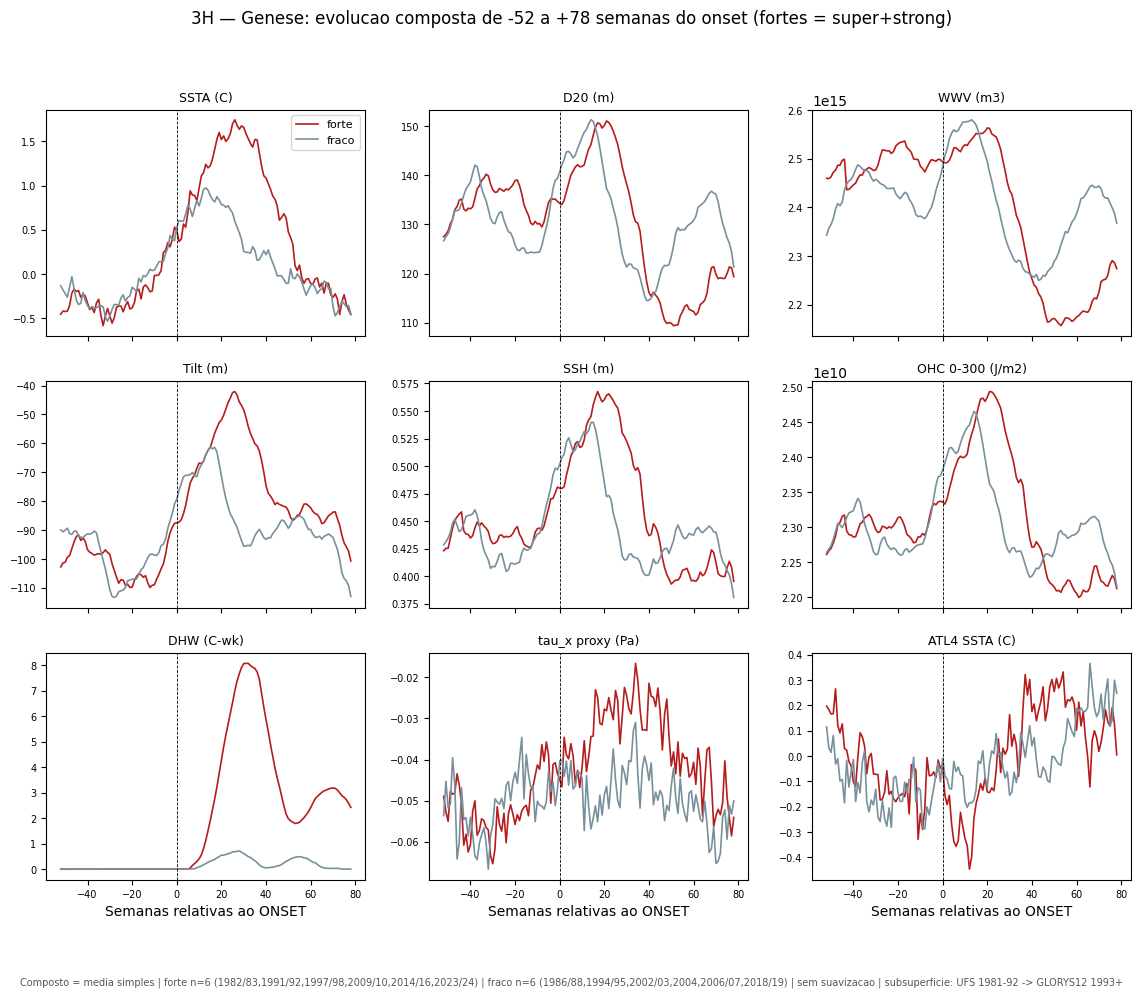

In [5]:
# Figura 3H-1: compostos onset-alinhados fortes vs fracos (multipainel)
labels = {'nino34_ssta':'SSTA (C)','d20_m':'D20 (m)','wwv':'WWV (m3)','tilt_m':'Tilt (m)',
          'ssh_m':'SSH (m)','ohc_0_300':'OHC 0-300 (J/m2)','dhw_12w':'DHW (C-wk)',
          'tau_x_proxy_nino34_pa':'tau_x proxy (Pa)','atl4_ssta':'ATL4 SSTA (C)'}
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True)
for ax, v in zip(axes.flat, VARS):
    for grupo, cor in [('forte','#b71c1c'), ('fraco','#78909c')]:
        ax.plot(LAGS, comps[grupo][v], color=cor, label=grupo, lw=1.2)
    ax.axvline(0, color='k', ls='--', lw=0.6)
    ax.set_title(labels[v], fontsize=9)
    ax.tick_params(labelsize=7)
axes.flat[0].legend(fontsize=8)
for ax in axes[-1]: ax.set_xlabel('Semanas relativas ao ONSET')
fig.suptitle('3H — Genese: evolucao composta de -52 a +78 semanas do onset (fortes = super+strong)')
fig.text(0.5, 0.005, 'Composto = media simples | forte n=6 (1982/83,1991/92,1997/98,2009/10,2014/16,2023/24) | fraco n=6 (1986/88,1994/95,2002/03,2004,2006/07,2018/19) | sem suavizacao | subsuperficie: UFS 1981-92 -> GLORYS12 1993+', ha='center', fontsize=7, color='#555')
u.save_fig(fig, 'phase3H_compostos_onset.png')
plt.show()

[figura] data/processed/figures/fase3/phase3H_retrato_genese.png


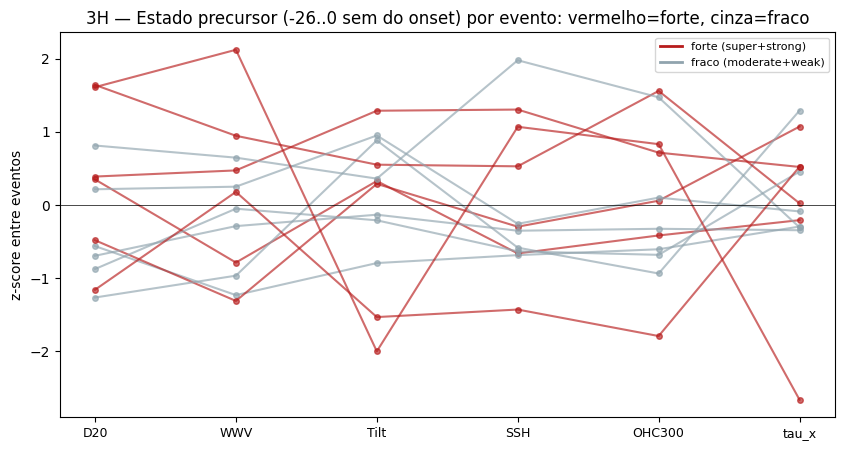

In [6]:
# Figura 3H-2: retrato da genese — precursores em -26..0 semanas, fortes vs fracos (normalizado)
pre_norm = []
for _, e in ev.iterrows():
    row = {'grupo': e.grupo, 'evento': e.event_id.replace('el_nino_oisst_','')}
    for v in ['d20_m','wwv','tilt_m','ssh_m','ohc_0_300','tau_x_proxy_nino34_pa']:
        s = onset_aligned(weekly[v], e.event_start)
        row[v] = s.loc[-26:0].mean()
    pre_norm.append(row)
pn = pd.DataFrame(pre_norm)
vars6 = ['d20_m','wwv','tilt_m','ssh_m','ohc_0_300','tau_x_proxy_nino34_pa']
z = (pn[vars6] - pn[vars6].mean()) / pn[vars6].std()
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(vars6))
for _, r in pn.iterrows():
    cor = '#b71c1c' if r.grupo == 'forte' else '#90a4ae'
    ax.plot(x, z.loc[r.name], color=cor, alpha=0.65, marker='o', ms=4,
            label=r.grupo if r.name in (0, len(pn)-1) else None)
ax.set_xticks(x); ax.set_xticklabels(['D20','WWV','Tilt','SSH','OHC300','tau_x'], fontsize=9)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('z-score entre eventos'); ax.set_title('3H — Estado precursor (-26..0 sem do onset) por evento: vermelho=forte, cinza=fraco')
handles = [plt.Line2D([0],[0],color='#b71c1c',lw=2,label='forte (super+strong)'), plt.Line2D([0],[0],color='#90a4ae',lw=2,label='fraco (moderate+weak)')]
ax.legend(handles=handles, fontsize=8)
u.save_fig(fig, 'phase3H_retrato_genese.png')
plt.show()

[figura] data/processed/figures/fase3/phase3H_storyline.png


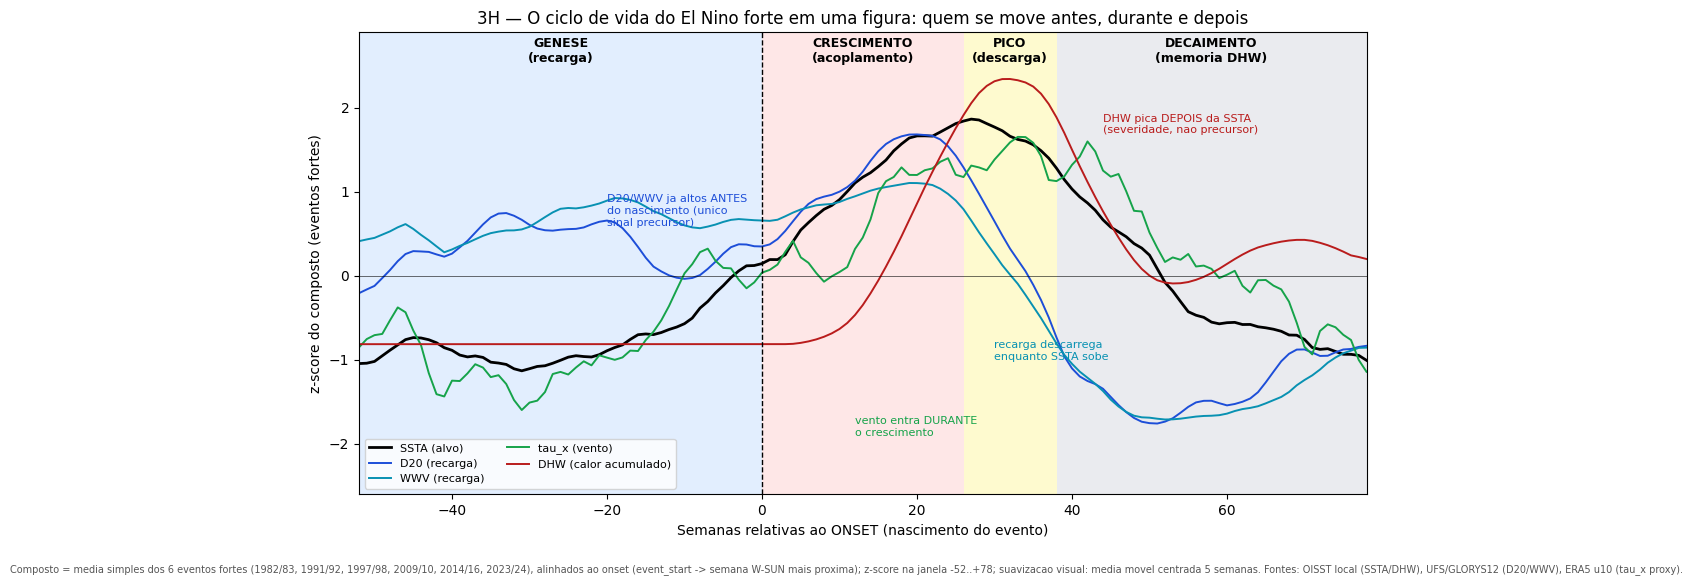

In [7]:
# Figura 3H-3 (sintese didatica): o ciclo em 4 fases, tudo em z-score, so eventos fortes
import matplotlib.patches as mpatches
f = comps['forte'][['nino34_ssta','d20_m','wwv','tau_x_proxy_nino34_pa','dhw_12w']].copy()
z = (f - f.mean()) / f.std()
z = z.rolling(5, center=True, min_periods=1).mean()  # suaviza para leitura

fases = [(-52, 0, '#dbeafe', 'GENESE\n(recarga)'), (0, 26, '#fee2e2', 'CRESCIMENTO\n(acoplamento)'),
         (26, 38, '#fef9c3', 'PICO\n(descarga)'), (38, 78, '#e5e7eb', 'DECAIMENTO\n(memoria DHW)')]
cores = {'nino34_ssta': ('#000000', 'SSTA (alvo)'), 'd20_m': ('#1d4ed8', 'D20 (recarga)'),
         'wwv': ('#0891b2', 'WWV (recarga)'), 'tau_x_proxy_nino34_pa': ('#16a34a', 'tau_x (vento)'),
         'dhw_12w': ('#b91c1c', 'DHW (calor acumulado)')}
fig, ax = plt.subplots(figsize=(13, 6))
for x0, x1, cor, rotulo in fases:
    ax.axvspan(x0, x1, color=cor, alpha=0.8, lw=0)
    ax.text((x0+x1)/2, 2.55, rotulo, ha='center', fontsize=9, weight='bold')
for v, (cor, rot) in cores.items():
    ax.plot(z.index, z[v], color=cor, lw=2 if v=='nino34_ssta' else 1.4, label=rot)
ax.axvline(0, color='k', ls='--', lw=1); ax.axhline(0, color='k', lw=0.4)
ax.annotate('D20/WWV ja altos ANTES\ndo nascimento (unico\nsinal precursor)', xy=(-20, 0.6), fontsize=8, color='#1d4ed8')
ax.annotate('vento entra DURANTE\no crescimento', xy=(12, -1.9), fontsize=8, color='#16a34a')
ax.annotate('recarga descarrega\nenquanto SSTA sobe', xy=(30, -1.0), fontsize=8, color='#0891b2')
ax.annotate('DHW pica DEPOIS da SSTA\n(severidade, nao precursor)', xy=(44, 1.7), fontsize=8, color='#b91c1c')
ax.set_xlim(-52, 78); ax.set_ylim(-2.6, 2.9)
ax.set_xlabel('Semanas relativas ao ONSET (nascimento do evento)'); ax.set_ylabel('z-score do composto (eventos fortes)')
ax.set_title('3H — O ciclo de vida do El Nino forte em uma figura: quem se move antes, durante e depois')
ax.legend(loc='lower left', fontsize=8, ncol=2)
fig.text(0.5, -0.02, 'Composto = media simples dos 6 eventos fortes (1982/83, 1991/92, 1997/98, 2009/10, 2014/16, 2023/24), alinhados ao onset (event_start -> semana W-SUN mais proxima); z-score na janela -52..+78; suavizacao visual: media movel centrada 5 semanas. Fontes: OISST local (SSTA/DHW), UFS/GLORYS12 (D20/WWV), ERA5 u10 (tau_x proxy).', ha='center', fontsize=7, color='#555')
u.save_fig(fig, 'phase3H_storyline.png')
plt.show()

**Como ler a figura-síntese:** todas as curvas estão em z-score (desvios da própria média), então "alto/baixo" é comparável entre variáveis. A sequência temporal das curvas É a física do ciclo: azul (recarga) sobe **antes** do tracejado (onset) → preto (SSTA) define o evento → verde (vento) desloca-se **durante** o crescimento → azul despenca (descarga) perto do pico → vermelho (DHW) pica **depois**. Quem se move antes do onset é candidato a precursor; quem se move junto é acoplamento; quem se move depois é consequência/memória.

**Leitura do 3H — a narrativa do ciclo de vida.**

**Gênese (−26 a 0 semanas do onset):** a diferença entre eventos que virarão fortes e fracos aparece primeiro na **recarga subsuperficial** — D20 mais fundo, WWV mais alto e OHC elevado antes mesmo de a SSTA cruzar 0,5 °C. É o pré-condicionamento do oscilador recarga-descarga: o calor precisa estar armazenado antes de o evento nascer.

**Crescimento (onset → pico, ~2–4 trimestres):** o τx (vento zonal) acopla-se à SSTA — anomalias de oeste empurram calor para leste (pulsos de Kelvin visíveis no SSH do 3F); tilt e SSH crescem em fase com a SSTA (por isso lag 0/6 no 3C); a subsuperfície começa a **descarregar**: D20/WWV caem à medida que a superfície esquenta.

**Pico:** máximo da SSTA com subsuperfície já parcialmente descarregada — o D20 no pico é menor que na gênese (assinatura de descarga). O DHW ainda está subindo (integrador).

**Decaimento:** a descarga completa-se (WWV mínimo), o acoplamento de vento se desfaz e a SSTA cai mais rápido do que cresceu (assimetria do 3B); o DHW pica +4..+11 semanas após a SSTA e decai lentamente — a memória do estresse térmico sobrevive ao evento.

**Sobre "prever" super eventos:** com 3 super eventos na base, nenhuma estatística separa formalmente super de strong. O que os dados sustentam: (i) o estado de recarga pré-onset ordena a intensidade final (Spearman da tabela 3H-2); (ii) no composto do 3B, super separa dos demais ~6 meses antes do pico; (iii) a combinação candidata a preditor para a Fase 5 é **recarga pré-onset (D20/WWV) + τx no crescimento + trajetória da própria SSTA**, avaliada por walk-forward contra persistência (baseline: e-folding 27 semanas). Prometer mais que isso seria ultrapassar o que a Fase 3 pode defender.